### Basic Deep Agent

In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent
from langchain.agents import create_agent

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

c:\Users\viren\generative-ai-implementations\langchain\langchain-updated\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Tools - Internet Search
tavily_client = TavilyClient(api_key=tavily_api_key)

def web_search(
    query:str, max_results:int=5, 
    topic:Literal["general", "sports", "news", "finance"]="general", 
    include_raw_content:bool=False):
    """Run a Web Search"""
    return tavily_client.search(query=query, max_results=max_results, topic=topic, include_raw_content=include_raw_content)

In [3]:
# Model Initialization
llm = ChatGroq(model="openai/gpt-oss-120b", api_key=groq_api_key)

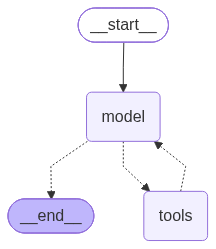

In [4]:
# Example of Simple Agent which we use to define previously
agent = create_agent( 
    model=llm,
    tools=[web_search],
    system_prompt='Act as a helpful assistant'
)

agent

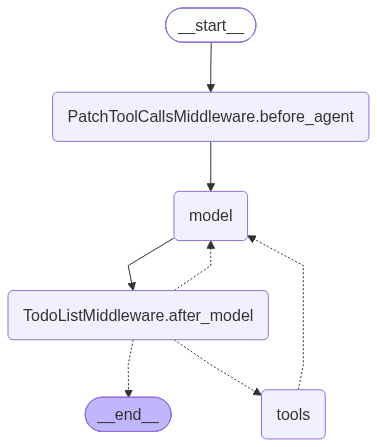

In [5]:
# Create a Deep Agent 
deep_agent = create_deep_agent(
    model=llm,
    tools=[web_search],
    system_prompt="Act as a researcher"
)

deep_agent

In [6]:
result = deep_agent.invoke({"messages": [{"role": "user", "content": "what is langchain?"}]})

In [7]:
print(result["messages"][-1].content)

LangChain is an open‑source framework for building applications powered by language models. It provides modular components—such as prompts, memory, agents, data connectors, and evaluation utilities—that let developers orchestrate LLM calls, integrate external data sources, manage conversational state, and chain together complex reasoning steps. By abstracting common patterns (prompt templates, retrieval‑augmented generation, tool use, etc.), LangChain simplifies the creation of robust, production‑ready LLM‑driven systems.
